# SEED-OLF Phase 2: Odor-Controlled Channel Features

## tl;dr

- **Data gate:** 2,304 paired trials from 32 participants passed schema and finite-value checks; all 2,480 channel features were finite with no zero-variance feature.
- **Primary result:** LOSO odor prior M0 log loss was **0.4411**. Odor + residualized channel log-power M2 was **0.4786**.
- M2 mean paired log-loss improvement was **-0.0376** (95% CI **-0.0661 to -0.0096**); positive would favor EEG.
- The strongest LOSO ranking model was **M5** with AUROC **0.8548**, but no channel model beat M0 on probabilistic loss.
- All 20 odor-stratified label-permutation controls failed the success gate; median permuted LOSO improvement was **-0.0356**.
- **Classification: `signal_without_passage`.** Ranking signal is present, but reliable incremental probability value is not established.


## Context & Methods

The question is whether channel-resolved EEG improves held-out prediction of the public binary subjective-valence proxy beyond odor identity. M2 is the single primary EEG comparison. All odor residualization, scaling, clipping, and tuning are fit inside training folds.

### Key Assumptions

- Sampling rate is assumed to be 200 Hz from 3,000 samples over the reported 15-second stage.
- Channels are array indices `ch00`–`ch61`; no electrode or topographic claim is made.
- `clean_breathing` is post-stimulus recovery, not a causal pre-stimulus baseline.
- `y_emotion` is a methodological proxy, not relaxation or a clinical outcome.


In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
OUTPUT_DIR = Path('artifacts/phase2_channel')
profile = json.loads((OUTPUT_DIR / "data_quality_profile.json").read_text())
metadata = json.loads((OUTPUT_DIR / "run_metadata.json").read_text())
summary = pd.read_csv(OUTPUT_DIR / "prediction_summary.csv")
incremental = pd.read_csv(OUTPUT_DIR / "incremental_value.csv")
equivalence = pd.read_csv(OUTPUT_DIR / "logbp_de_equivalence.csv")
negative = pd.read_csv(OUTPUT_DIR / "negative_control_summary.csv")
validation = json.loads((OUTPUT_DIR / "validation_checks.json").read_text())


## Data

### 1. Check dataset and feature quality

In [2]:
quality = pd.DataFrame(profile["signal_qc_by_phase"]).T
display(pd.Series({
    "trials": profile["n_trials"],
    "subjects": profile["n_subjects"],
    "participant_sessions": profile["n_sessions"],
    "feature_count": profile["feature_count"],
    "finite_feature_rate": profile["finite_feature_rate"],
    "zero_variance_features": profile["zero_variance_features"],
}, name="value").to_frame())
display(quality)


,value
trials,2304.0
subjects,32.0
participant_sessions,96.0
feature_count,2480.0
finite_feature_rate,1.0
zero_variance_features,0.0


,records,flat_channel_records,maximum_flat_channels,de_floor_value_rate,peak_abs_quantile_99,median_channel_std_quantile_01
recovery,2304.0,0.0,0.0,0.0,0.001637,0.000006
stim,2304.0,0.0,0.0,0.0,0.002001,0.000007


## Results

### 2. Compare held-out probabilistic performance

,protocol,model,n_trials,prevalence,log_loss,brier,balanced_accuracy,roc_auc,pr_auc,calibration_intercept,calibration_slope,ece_10_equal_frequency
0,losession,M0,2304,0.4332,0.4135,0.1299,0.8247,0.8869,0.8528,-0.0620,1.0506,0.0282
1,losession,M1,2304,0.4332,0.4263,0.1351,0.8067,0.8831,0.8462,-0.0191,0.8869,0.0374
2,losession,M2,2304,0.4332,0.6726,0.2379,0.5673,0.6087,0.5612,-0.1220,0.4926,0.0753
3,losession,M3,2304,0.4332,0.6602,0.2351,0.5675,0.6137,0.5644,-0.1143,0.5769,0.0682
4,losession,M4,2304,0.4332,0.6533,0.2295,0.5729,0.6353,0.5812,-0.1162,0.5685,0.0629
5,losession,M5,2304,0.4332,0.6412,0.2246,0.5999,0.6608,0.6250,-0.0666,0.5936,0.0707
6,loso,M0,2304,0.4332,0.4411,0.1385,0.8093,0.8142,0.7593,-0.0087,0.9799,0.1157
7,loso,M1,2304,0.4332,0.4409,0.1385,0.8093,0.8142,0.7470,-0.0029,0.9919,0.1153
8,loso,M2,2304,0.4332,0.4786,0.1524,0.7765,0.8465,0.8154,0.0023,0.8593,0.0267
9,loso,M3,2304,0.4332,0.4772,0.1517,0.7790,0.8491,0.8107,0.0079,0.8724,0.0276


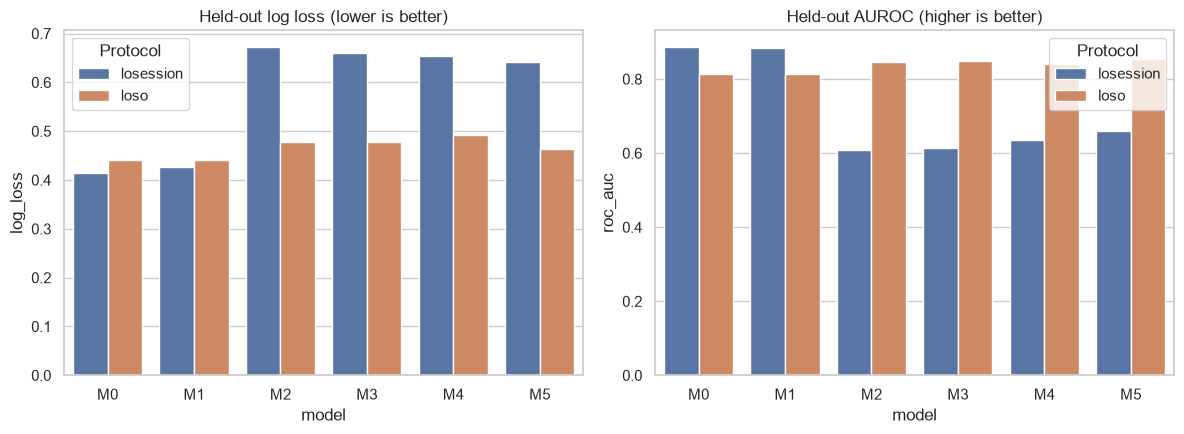

In [3]:
display(summary.round(4))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(data=summary, x="model", y="log_loss", hue="protocol", ax=axes[0])
sns.barplot(data=summary, x="model", y="roc_auc", hue="protocol", ax=axes[1])
axes[0].set_title("Held-out log loss (lower is better)")
axes[1].set_title("Held-out AUROC (higher is better)")
for axis in axes:
    axis.legend(title="Protocol")
plt.tight_layout()
plt.show()


### 3. Inspect paired incremental value and uncertainty

,protocol,candidate,baseline,n_subjects,n_trials,mean_log_loss_improvement,log_loss_ci95_lower,log_loss_ci95_upper,mean_brier_improvement,brier_ci95_lower,brier_ci95_upper,participants_improved_rate,delete_odor_1_log_loss_improvement,delete_odor_2_log_loss_improvement,delete_odor_3_log_loss_improvement,delete_odor_4_log_loss_improvement,participant_wilcoxon_p_value,participant_wilcoxon_q_value
0,loso,M1,M0,32,2304,0.0001,-0.0006,0.0011,0.0000,-0.0001,0.0002,0.4375,0.0001,0.0001,0.0001,0.0002,0.5483,NaN
1,loso,M2,M0,32,2304,-0.0376,-0.0661,-0.0096,-0.0139,-0.0247,-0.0035,0.2188,-0.0356,-0.0452,-0.0342,-0.0353,0.0034,NaN
2,loso,M3,M0,32,2304,-0.0361,-0.0611,-0.0104,-0.0132,-0.0226,-0.0038,0.2188,-0.0350,-0.0469,-0.0312,-0.0314,0.0024,0.0029
3,loso,M4,M0,32,2304,-0.0510,-0.0724,-0.0315,-0.0164,-0.0229,-0.0103,0.0625,-0.0493,-0.0537,-0.0524,-0.0485,0.0000,0.0000
4,loso,M5,M0,32,2304,-0.0220,-0.0442,-0.0004,-0.0084,-0.0171,-0.0002,0.3125,-0.0177,-0.0271,-0.0214,-0.0218,0.0253,0.0253
5,losession,M1,M0,32,2304,-0.0128,-0.0316,0.0033,-0.0052,-0.0100,-0.0013,0.4688,NaN,NaN,NaN,NaN,0.2781,NaN
6,losession,M2,M0,32,2304,-0.2592,-0.3091,-0.2067,-0.1080,-0.1276,-0.0882,0.0625,NaN,NaN,NaN,NaN,0.0000,NaN
7,losession,M3,M0,32,2304,-0.2467,-0.2968,-0.1931,-0.1052,-0.1252,-0.0849,0.0625,NaN,NaN,NaN,NaN,0.0000,0.0000
8,losession,M4,M0,32,2304,-0.2399,-0.2957,-0.1808,-0.0996,-0.1204,-0.0777,0.0625,NaN,NaN,NaN,NaN,0.0000,0.0000
9,losession,M5,M0,32,2304,-0.2277,-0.2752,-0.1790,-0.0947,-0.1129,-0.0760,0.0312,NaN,NaN,NaN,NaN,0.0000,0.0000


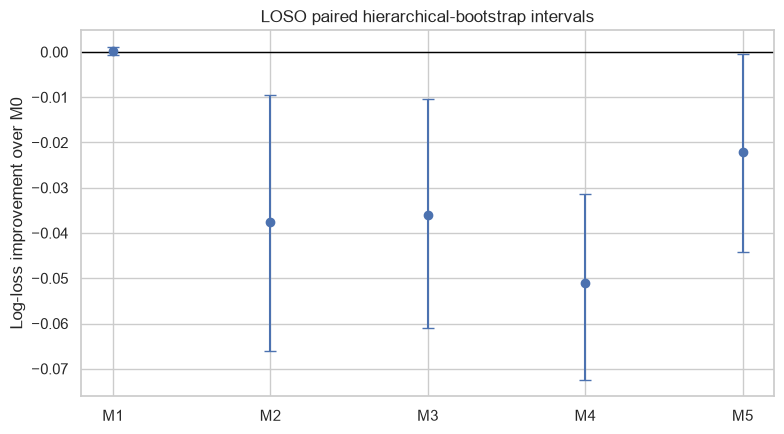

In [4]:
display(incremental.round(4))
loso = incremental[incremental.protocol == "loso"].copy()
fig, ax = plt.subplots(figsize=(8, 4.5))
errors = np.vstack([
    loso.mean_log_loss_improvement - loso.log_loss_ci95_lower,
    loso.log_loss_ci95_upper - loso.mean_log_loss_improvement,
])
ax.errorbar(loso.candidate, loso.mean_log_loss_improvement, yerr=errors, fmt="o", capsize=4)
ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("Log-loss improvement over M0")
ax.set_title("LOSO paired hierarchical-bootstrap intervals")
plt.tight_layout()
plt.show()


### 4. Quantify log-power and DE equivalence

,outer_test_subject,median_correlation,minimum_correlation,maximum_correlation,proportion_abs_correlation_ge_0_95
count,32.0000,32.0000,32.0000,32.0000,32.0000
mean,16.5000,0.9952,0.8777,0.9991,0.9325
std,9.3808,0.0002,0.0121,0.0001,0.0116
min,1.0000,0.9944,0.8687,0.9990,0.9065
25%,8.7500,0.9951,0.8749,0.9990,0.9290
50%,16.5000,0.9952,0.8767,0.9991,0.9323
75%,24.2500,0.9953,0.8775,0.9991,0.9323
max,32.0000,0.9956,0.9423,0.9993,0.9903


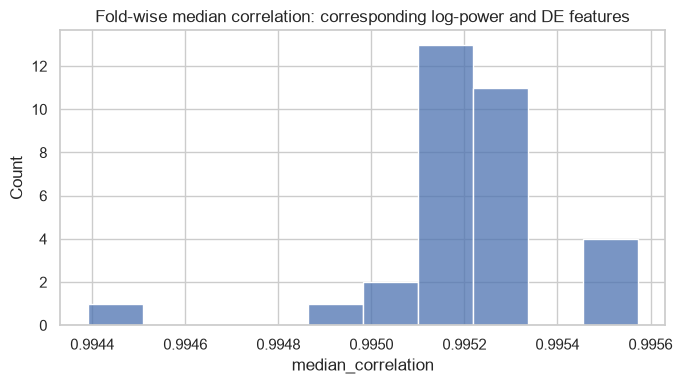

In [5]:
display(equivalence.describe().round(4))
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(equivalence.median_correlation, bins=10, ax=ax)
ax.set_title("Fold-wise median correlation: corresponding log-power and DE features")
plt.tight_layout()
plt.show()


### 5. Check odor-stratified label permutations

,permutation,seed,classification,all_statistical_gates_pass,loso_log_loss_improvement,loso_log_loss_ci95_lower
0,1,20260811,signal_without_passage,False,-0.0376,-0.0644
1,2,20260812,signal_without_passage,False,-0.0523,-0.0795
2,3,20260813,signal_without_passage,False,-0.0399,-0.0730
3,4,20260814,signal_without_passage,False,-0.0355,-0.0578
4,5,20260815,signal_without_passage,False,-0.0418,-0.0694
5,6,20260816,signal_without_passage,False,-0.0333,-0.0605
6,7,20260817,signal_without_passage,False,-0.0401,-0.0661
7,8,20260818,signal_without_passage,False,-0.0367,-0.0729
8,9,20260819,signal_without_passage,False,-0.0326,-0.0562
9,10,20260820,signal_without_passage,False,-0.0195,-0.0411


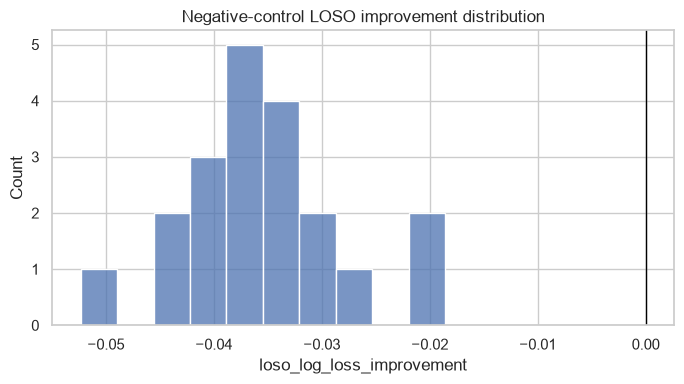

In [6]:
display(negative.round(4))
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(negative.loso_log_loss_improvement, bins=10, ax=ax)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Negative-control LOSO improvement distribution")
plt.tight_layout()
plt.show()


## Takeaways

1. Channel-level EEG contains some held-out ranking information, but the preregistered M2 probability-value gate fails.
2. Robust clipping/scaling reduces M2's damage but does not establish positive incremental log loss.
3. Within-participant cross-session performance is substantially worse than odor-only prediction, so the current 310-dimensional representation is not ready for few-shot personalization without stronger shrinkage or lower-dimensional structure.
4. DE and log-power are highly correlated and should remain separate comparisons rather than a concatenated feature expansion.
5. These results justify completing the planned Phase 3 calibration-curve baseline, but they do not justify promoting EEGNet or TSception as likely solutions yet.
